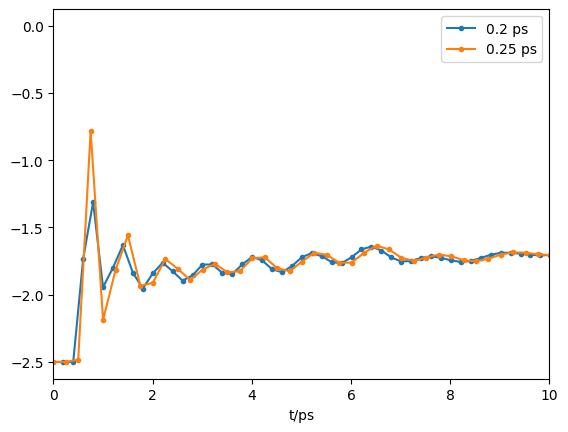

TYPE: <class 'dict'>
ITEM: {'x': array([[-5.e-10,  0.e+00,  0.e+00],
       [-5.e-10,  0.e+00,  0.e+00],
       [-5.e-10,  0.e+00,  0.e+00],
       ...,
       [-5.e-10,  0.e+00,  0.e+00],
       [-5.e-10,  0.e+00,  0.e+00],
       [-5.e-10,  0.e+00,  0.e+00]]), 'final heat': 0.10379181399622485, 'full heats': array([0.        , 0.00588121, 0.01999638, 0.03599441, 0.05000121,
       0.06097991, 0.06924102, 0.07540379, 0.08002958, 0.08354594,
       0.08625916, 0.08838467, 0.0900742 , 0.09143561, 0.09254657,
       0.09346377, 0.09422911, 0.09487404, 0.0954224 , 0.09589253,
       0.09629868, 0.09665205, 0.09696152, 0.09723422, 0.09747589,
       0.09769122, 0.09788405, 0.09805755, 0.09821435, 0.09835666,
       0.09848632, 0.0986049 , 0.09871373, 0.09881394, 0.09890651,
       0.09899227, 0.09907195, 0.09914618, 0.09921551, 0.09928042,
       0.09934134, 0.09939864, 0.09945265, 0.09950367, 0.09955195,
       0.09959773, 0.09964123, 0.09968263, 0.09972209, 0.09975978,
       0.09979582,

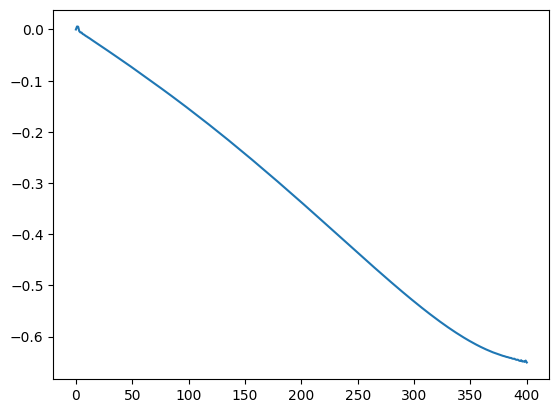

In [2]:
import dill
import matplotlib.pyplot as plt
import numpy as np

for dt in [0.2,0.25]:
    with open('results/zero_control_10K/conv_checks/dt={0}_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0/100ps'.format(dt), 'rb') as f:
        opt_dict = dill.load(f)


    hx = opt_dict['log'][20]['x'][:,0::3][0::2]

    t_prot = 100
    num_steps = len(hx)

    times=np.linspace(0,t_prot,num_steps)

    plt.plot(times,hx,marker='.',label='{0} ps'.format(dt))
plt.xlim(0,10)
plt.xlabel('t/ps')
plt.legend()
plt.show()
#hy = opt_dict['result'].x[1::3]
#hz = opt_dict['result'].x[2::3]


#plt.plot(times,hy,label='hy')
#plt.plot(times,hz,label='hz')


entry0 = opt_dict['log'][0]
print("TYPE:", type(entry0))
print("ITEM:", entry0)

print(opt_dict['log'][-1]['full heats'].shape)
plt.plot(opt_dict['log'][-1]['full heats'])


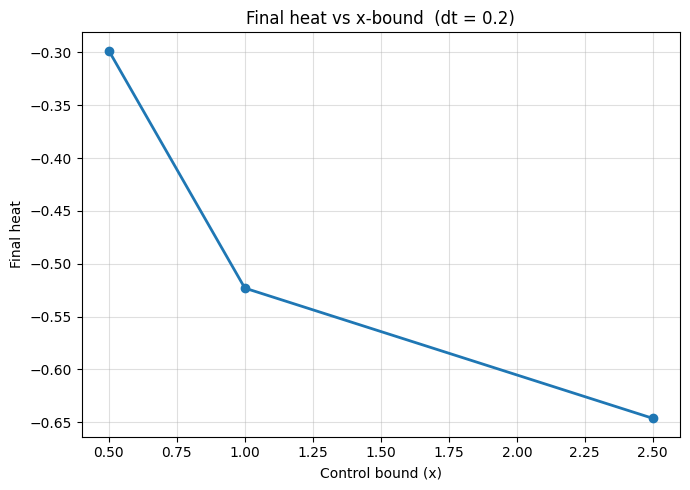

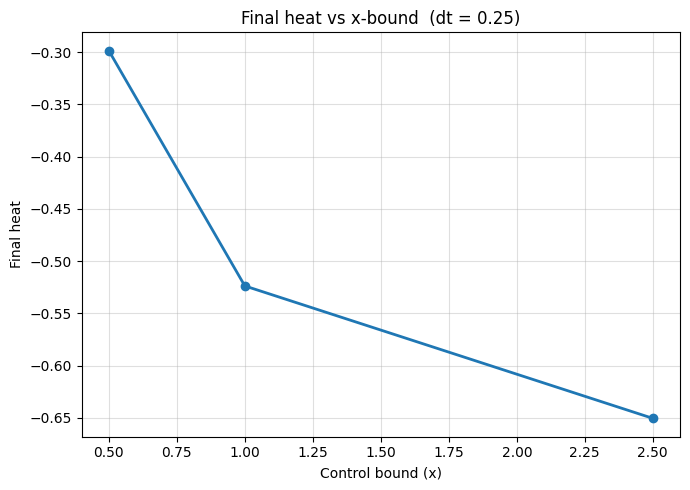

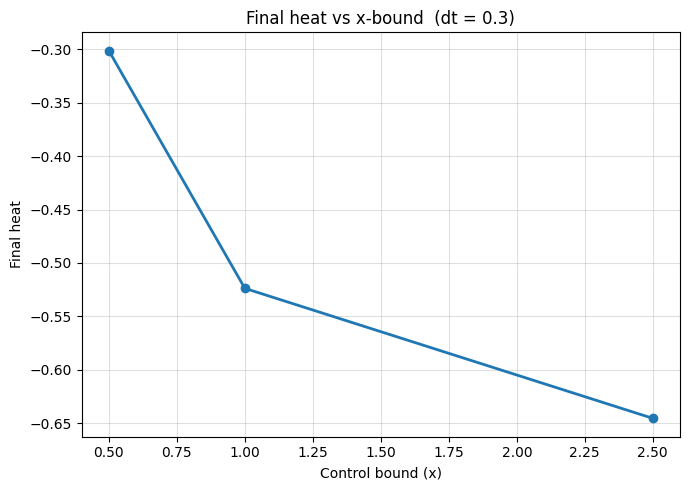

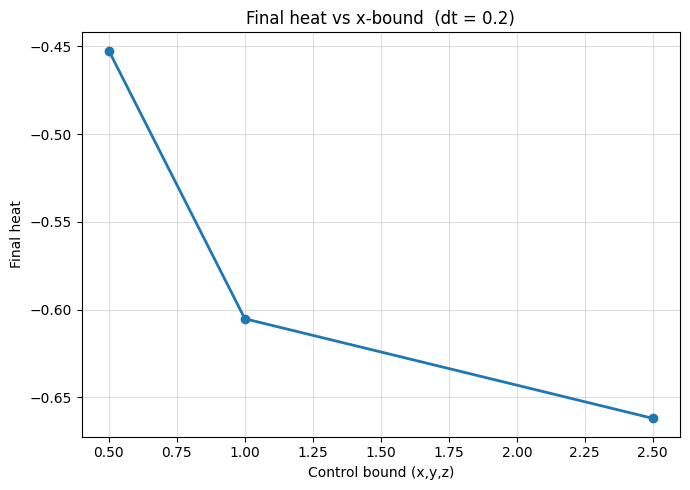

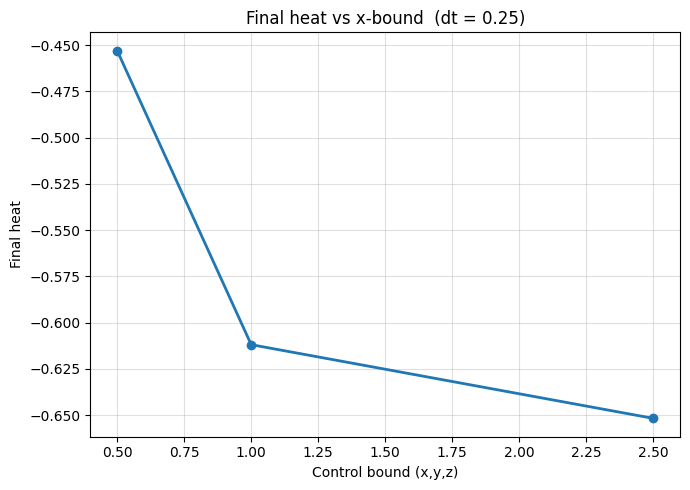

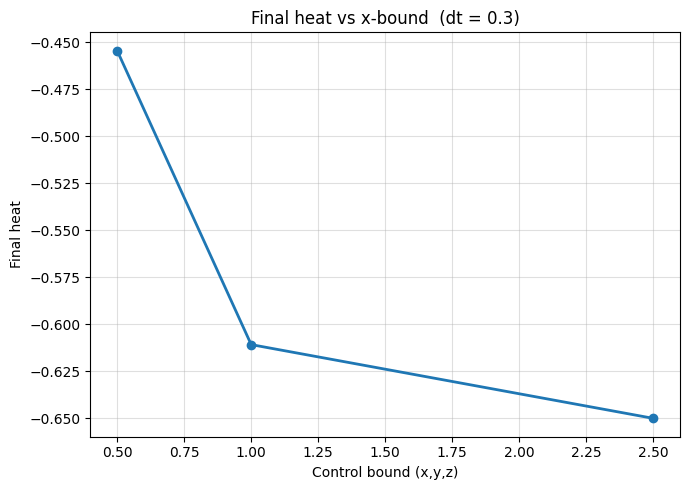

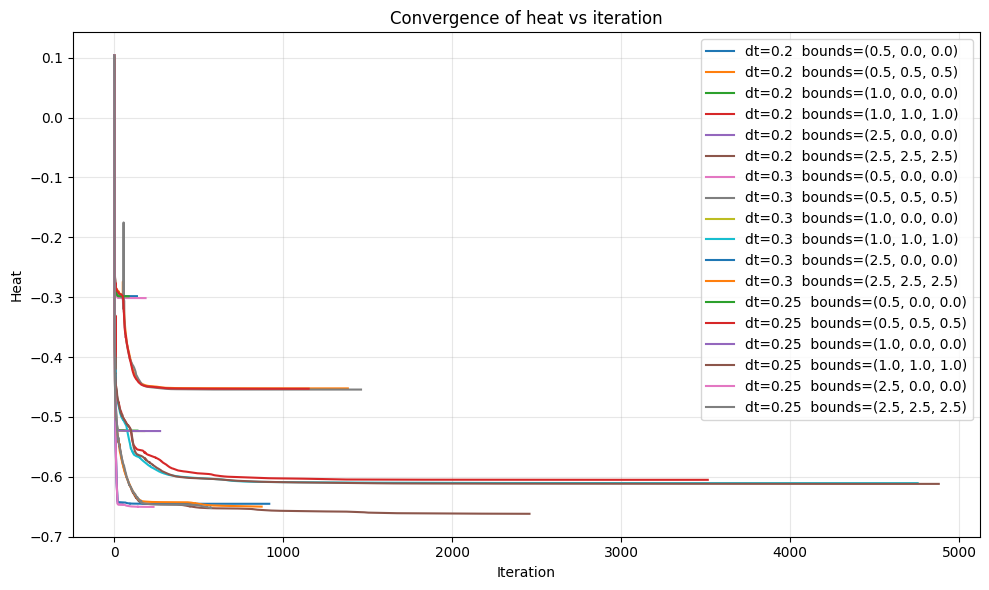

In [6]:
import dill
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# ---------------------------------------------------------
# Parse metadata from filename
# ---------------------------------------------------------
def parse_dirname(dirname):
    pattern = r"dt=([\d\.]+)_ps=.*?_x=([\d\.]+)_y=([\d\.]+)_z=([\d\.]+)"
    m = re.search(pattern, dirname)
    if not m:
        return None
    dt = float(m.group(1))
    bounds = (float(m.group(2)), float(m.group(3)), float(m.group(4)))
    return dt, bounds

# ---------------------------------------------------------
# Find the correct dill file inside the folder
# ---------------------------------------------------------
def find_opt_file(folder):
    files = os.listdir(folder)
    # Prefer files with no extension (your "500ps" files)
    for f in files:
        if "." not in f:
            return os.path.join(folder, f)
    # Next try .pkl/.pickle/.dill
    for f in files:
        if f.endswith((".pkl", ".pickle", ".dill")):
            return os.path.join(folder, f)
    raise FileNotFoundError(f"No opt file found in {folder}")

def load_opt_dict(folder):
    path = find_opt_file(folder)
    with open(path, "rb") as f:
        return dill.load(f)

# ---------------------------------------------------------
# Folders to load
# ---------------------------------------------------------

folders = [
    "results/zero_control_10K/conv_checks/dt=0.2_ps=-6.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.2_ps=-6.0_tcut=500_x=0.5_y=0.5_z=0.5",
    "results/zero_control_10K/conv_checks/dt=0.2_ps=-6.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.2_ps=-6.0_tcut=500_x=1.0_y=1.0_z=1.0",
    "results/zero_control_10K/conv_checks/dt=0.2_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.2_ps=-6.0_tcut=500_x=2.5_y=2.5_z=2.5",
    "results/zero_control_10K/conv_checks/dt=0.3_ps=-6.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.3_ps=-6.0_tcut=500_x=0.5_y=0.5_z=0.5",
    "results/zero_control_10K/conv_checks/dt=0.3_ps=-6.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.3_ps=-6.0_tcut=500_x=1.0_y=1.0_z=1.0",
    "results/zero_control_10K/conv_checks/dt=0.3_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.3_ps=-6.0_tcut=500_x=2.5_y=2.5_z=2.5",
    "results/zero_control_10K/conv_checks/dt=0.25_ps=-6.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.25_ps=-6.0_tcut=500_x=0.5_y=0.5_z=0.5",
    "results/zero_control_10K/conv_checks/dt=0.25_ps=-6.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.25_ps=-6.0_tcut=500_x=1.0_y=1.0_z=1.0",
    "results/zero_control_10K/conv_checks/dt=0.25_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "results/zero_control_10K/conv_checks/dt=0.25_ps=-6.0_tcut=500_x=2.5_y=2.5_z=2.5",
]


# ---------------------------------------------------------
# Load all runs
# ---------------------------------------------------------
all_data = []

for folder in folders:
    meta = parse_dirname(folder)
    if meta is None:
        continue
    dt, bounds = meta

    opt_dict = load_opt_dict(folder)

    # Extract correct log info:
    logs = opt_dict["log"]
    final_heat = logs[-1]["final heat"]
    heats = [entry["final heat"] for entry in logs]

    all_data.append({
        "dt": dt,
        "bounds": bounds,
        "final_heat": final_heat,
        "heats": heats
    })

# ---------------------------------------------------------
# Identify unique dt values
# ---------------------------------------------------------
unique_dts = sorted(list({entry["dt"] for entry in all_data}))

# ---------------------------------------------------------
# PLOT 1 & PLOT 2: Final heat vs bounds for each dt
# ---------------------------------------------------------
for dt_value in unique_dts:
    subset = [entry for entry in all_data if entry["dt"] == dt_value and entry["bounds"][1]==0.0]

    x_bounds = [b[0] for b in (entry["bounds"] for entry in subset)]
    y_bounds = [b[1] for b in (entry["bounds"] for entry in subset)]
    final_heats = [entry["final_heat"] for entry in subset]

    plt.figure(figsize=(7, 5))
    plt.plot(x_bounds, final_heats, "o-", linewidth=2)
    plt.xlabel("Control bound (x)")
    plt.ylabel("Final heat")
    plt.title(f"Final heat vs x-bound  (dt = {dt_value})")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

for dt_value in unique_dts:
    subset = [entry for entry in all_data if entry["dt"] == dt_value and entry["bounds"][1]!=0.0]

    x_bounds = [b[0] for b in (entry["bounds"] for entry in subset)]
    y_bounds = [b[1] for b in (entry["bounds"] for entry in subset)]
    final_heats = [entry["final_heat"] for entry in subset]

    plt.figure(figsize=(7, 5))
    plt.plot(x_bounds, final_heats, "o-", linewidth=2)
    plt.xlabel("Control bound (x,y,z)")
    plt.ylabel("Final heat")
    plt.title(f"Final heat vs x-bound  (dt = {dt_value})")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# PLOT 3: Convergence of heat vs iteration for all runs
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for entry in all_data:
    heats = entry["heats"]
    label = f"dt={entry['dt']}  bounds={entry['bounds']}"
    plt.plot(np.arange(len(heats)), heats, label=label, linewidth=1.5)

plt.xlabel("Iteration")
plt.ylabel("Heat")
plt.title("Convergence of heat vs iteration")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


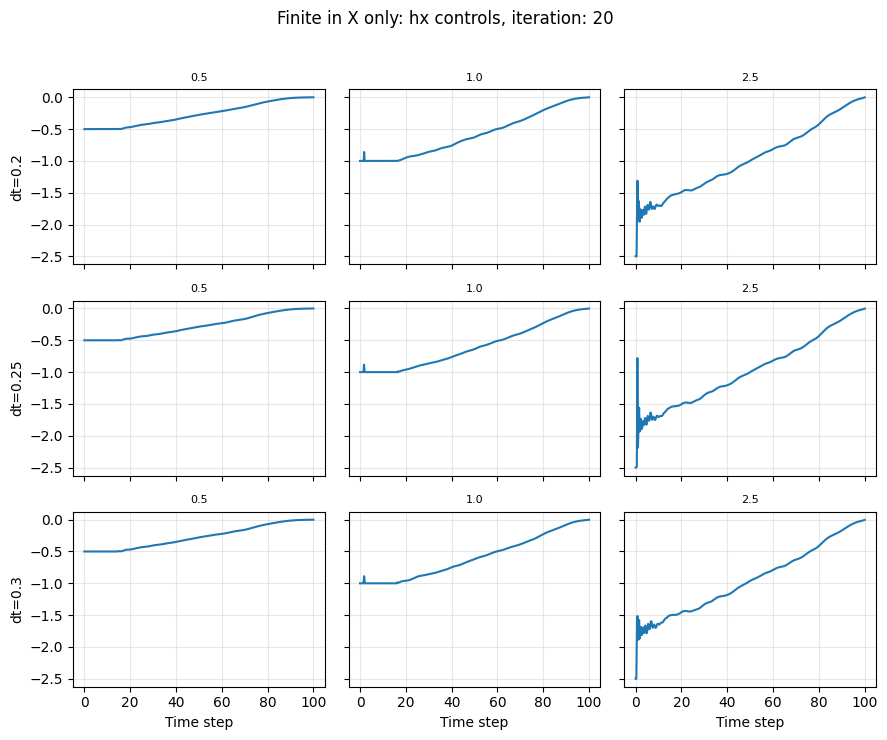

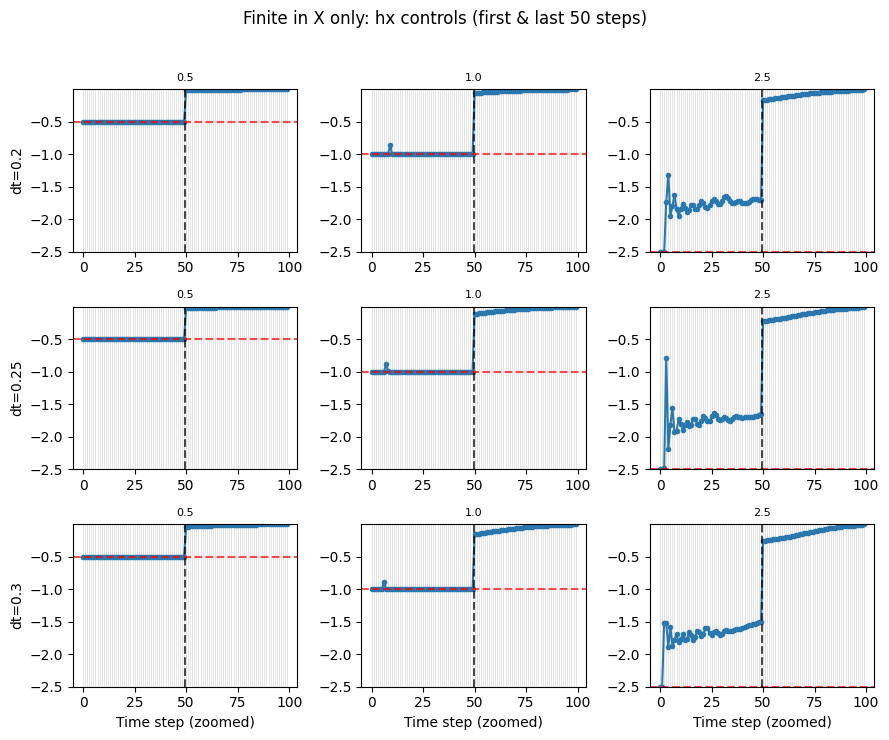

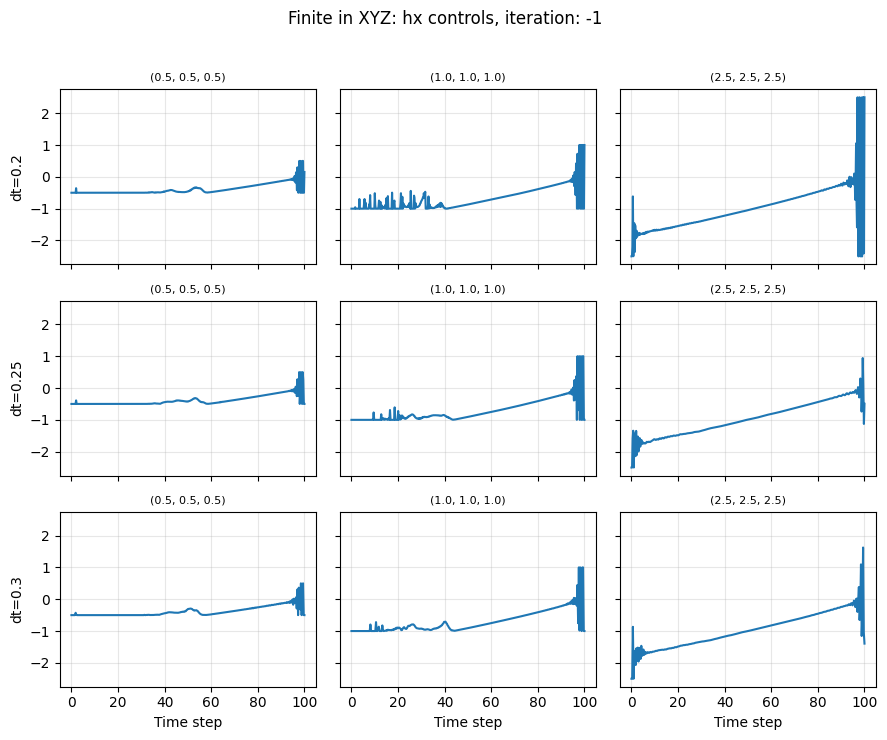

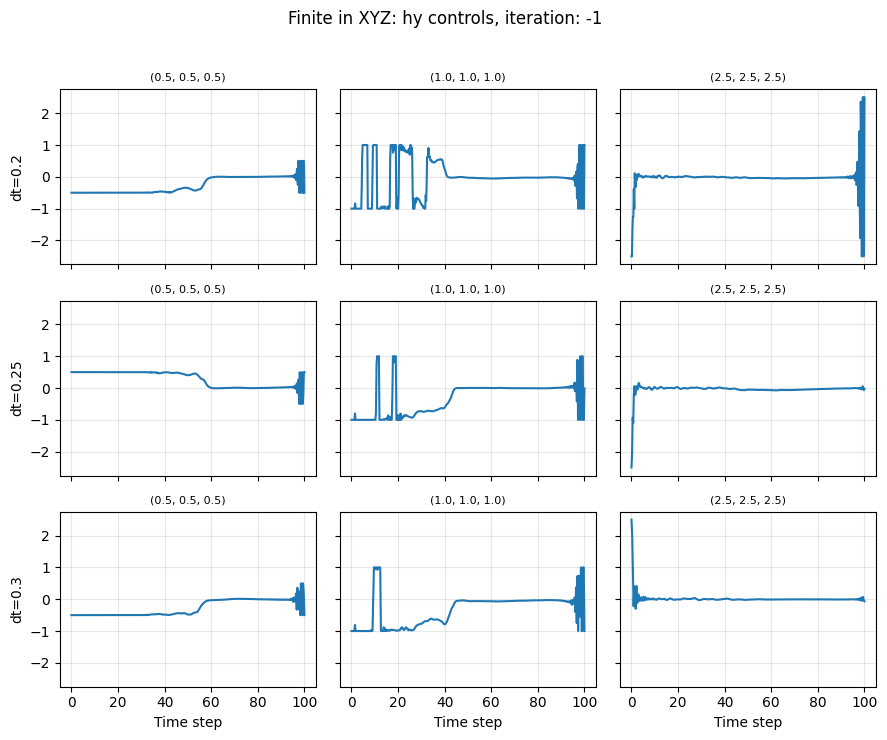

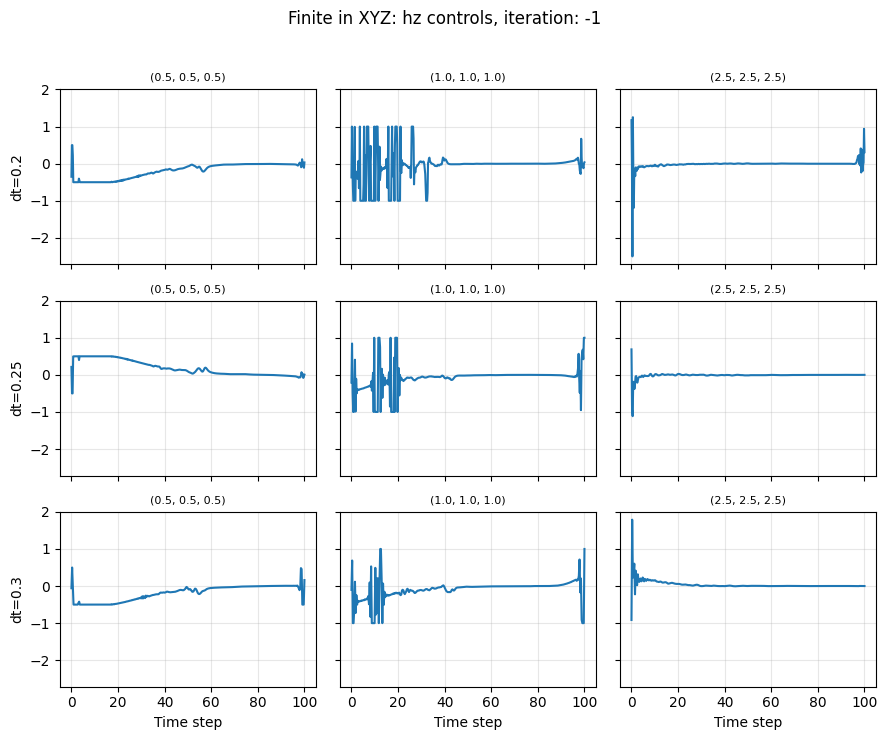

In [ ]:
import os
import dill
import numpy as np
import matplotlib.pyplot as plt

base_dir = "results/zero_control_10K/conv_checks"

folders = [
    "dt=0.2_ps=-6.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "dt=0.2_ps=-6.0_tcut=500_x=0.5_y=0.5_z=0.5",
    "dt=0.2_ps=-6.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "dt=0.2_ps=-6.0_tcut=500_x=1.0_y=1.0_z=1.0",
    "dt=0.2_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "dt=0.2_ps=-6.0_tcut=500_x=2.5_y=2.5_z=2.5",
    "dt=0.3_ps=-6.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "dt=0.3_ps=-6.0_tcut=500_x=0.5_y=0.5_z=0.5",
    "dt=0.3_ps=-6.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "dt=0.3_ps=-6.0_tcut=500_x=1.0_y=1.0_z=1.0",
    "dt=0.3_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "dt=0.3_ps=-6.0_tcut=500_x=2.5_y=2.5_z=2.5",
    "dt=0.25_ps=-6.0_tcut=500_x=0.5_y=0.0_z=0.0",
    "dt=0.25_ps=-6.0_tcut=500_x=0.5_y=0.5_z=0.5",
    "dt=0.25_ps=-6.0_tcut=500_x=1.0_y=0.0_z=0.0",
    "dt=0.25_ps=-6.0_tcut=500_x=1.0_y=1.0_z=1.0",
    "dt=0.25_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0",
    "dt=0.25_ps=-6.0_tcut=500_x=2.5_y=2.5_z=2.5",
]

t_prot=100


i


# -------------------------------------------------------------
# Classify folders by bound type and dt
# -------------------------------------------------------------
x_only = {}
xyz_all = {}
for folder in folders:
    parts = folder.split("_")
    dt = float(parts[0].split("=")[1])
    x = float(parts[-3].split("=")[1])
    y = float(parts[-2].split("=")[1])
    z = float(parts[-1].split("=")[1])
    
    if y == 0 and z == 0 and x > 0:
        x_only.setdefault(dt, []).append((x, folder))
    elif x > 0 and y > 0 and z > 0:
        xyz_all.setdefault(dt, []).append(((x, y, z), folder))

def get_controls(folder,iteration=-1):
    path = os.path.join(base_dir, folder, "100ps")
    opt_dict = load_opt_dict(path)
    if opt_dict is None:
        return None, None, None

    if iteration==-1:
        x_ctrl = opt_dict["result"].x[0::3]
        y_ctrl = opt_dict["result"].x[1::3]
        z_ctrl = opt_dict["result"].x[2::3]
    else:
        # accidently saved controls over half time-steps rather than full - just skip every second step
        x_ctrl = opt_dict["log"][iteration]["x"][:,0::3][0::2]
        y_ctrl = opt_dict["log"][iteration]["x"][:,1::3][0::2]
        z_ctrl = opt_dict["log"][iteration]["x"][:,2::3][0::2]
    return x_ctrl, y_ctrl, z_ctrl


def plot_control_grid(control_dict, title_prefix, control_label="hx",iteration=-1):
    dts = sorted(control_dict.keys())
    
    # determine number of columns for largest number of bounds per dt
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharex=True, sharey=True)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            

            hx, hy, hz = get_controls(folder,iteration)

            t=np.linspace(0,t_prot,len(hx))  

            ax = axes[i,j]
            if hx is None:
                continue
            if control_label == "hx":
                ax.plot(t,hx)
            elif control_label == "hy":
                ax.plot(t,hy)
            elif control_label == "hz":
                ax.plot(t,hz)
            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax.set_xlabel("Time step")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")
            ax.grid(alpha=0.3)
    plt.suptitle(f"{title_prefix}: {control_label} controls, iteration: {iteration}")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def plot_control_grid_zoom(control_dict, title_prefix, control_label="hx", n_edge=10,iteration=-1):
    dts = sorted(control_dict.keys())
    
    # First, find global y-axis limits
    all_y = []
    for dt in dts:
        for bounds, folder in control_dict[dt]:

            hx, hy, hz = get_controls(folder,iteration)

            if hx is None:
                continue
            ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
            yplot = np.concatenate([ydata[:n_edge], ydata[-n_edge:]])
            all_y.append(yplot)
    all_y = np.concatenate(all_y)
    global_ymin, global_ymax = np.min(all_y), np.max(all_y)
    
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharey=False)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            

            hx, hy, hz = get_controls(folder,iteration)
    
            ax = axes[i,j]
            if hx is None:
                continue
            
            ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
            N = len(ydata)
            

            yplot = np.concatenate([ydata[:n_edge], ydata[-n_edge:]])
            xplot = np.arange(len(yplot))
            
            ax.plot(xplot, yplot, color='C0',marker='.')
            
            # vertical lines 
            for xi in range(len(xplot)):
                ax.axvline(x=xi, color='gray', alpha=0.3, linewidth=0.5)
            

            #y_min, y_max = np.min(yplot), np.max(yplot)
            y_min,y_max=-bounds,bounds
            ax.axhline(y_min, color='red', linestyle='--', alpha=0.7)
            ax.axhline(y_max, color='red', linestyle='--', alpha=0.7)
            
            # dashed line 
            ax.axvline(n_edge-0.5, color='k', linestyle='--', alpha=0.7)
            

            ax.set_ylim(global_ymin, global_ymax)
            
            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax.set_xlabel("Time step (zoomed)")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")
    
    plt.suptitle(f"{title_prefix}: {control_label} controls (first & last {n_edge} steps)")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



plot_control_grid(x_only, "Finite in X only", control_label="hx",iteration=20)

plot_control_grid_zoom(x_only, "Finite in X only", control_label="hx", n_edge=50,iteration=20)

plot_control_grid(xyz_all, "Finite in XYZ", control_label="hx")
plot_control_grid(xyz_all, "Finite in XYZ", control_label="hy")
plot_control_grid(xyz_all, "Finite in XYZ", control_label="hz")


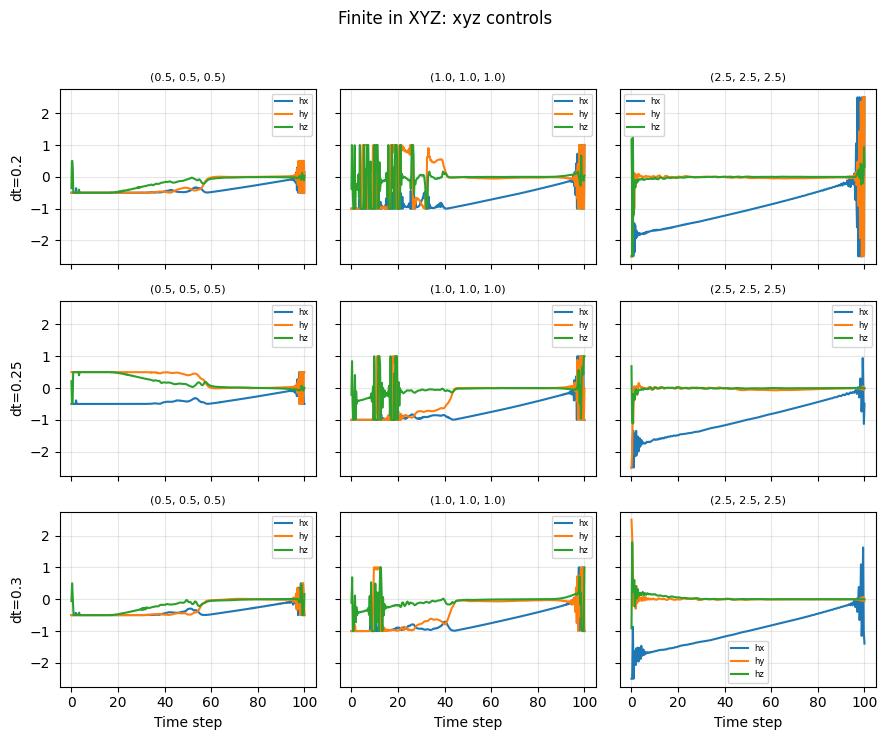

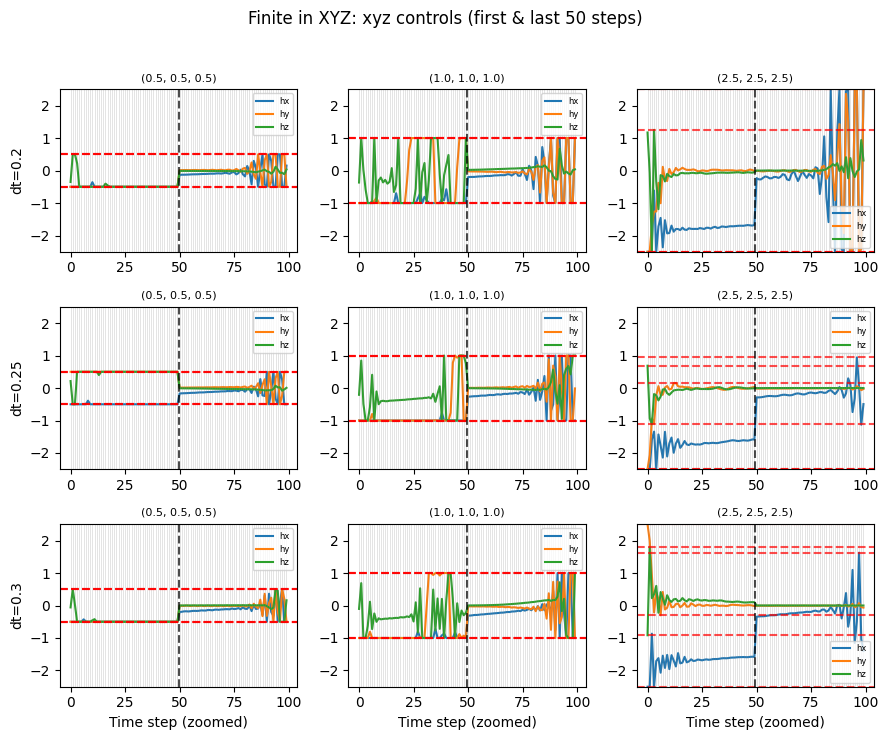

In [16]:
def plot_control_grid(control_dict, title_prefix, control_label="hx"):
    dts = sorted(control_dict.keys())
    
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharex=True, sharey=True)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            hx, hy, hz = get_controls(folder)
            t = np.linspace(0, t_prot, len(hx))  

            ax = axes[i,j]
            if hx is None:
                continue

            if control_label == "xyz":
                ax.plot(t, hx, label="hx")
                ax.plot(t, hy, label="hy")
                ax.plot(t, hz, label="hz")
                ax.legend(fontsize=6)
            else:
                ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
                ax.plot(t, ydata)
            
            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax.set_xlabel("Time step")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")
            ax.grid(alpha=0.3)
    plt.suptitle(f"{title_prefix}: {control_label} controls")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_control_grid_zoom(control_dict, title_prefix, control_label="hx", n_edge=10):
    dts = sorted(control_dict.keys())
    
    # Determine global y-axis limits across all controls
    all_y = []
    for dt in dts:
        for bounds, folder in control_dict[dt]:
            hx, hy, hz = get_controls(folder)
            if hx is None:
                continue
            if control_label == "xyz":
                yplot = np.concatenate([hx[:n_edge], hx[-n_edge:], hy[:n_edge], hy[-n_edge:], hz[:n_edge], hz[-n_edge:]])
            else:
                ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
                yplot = np.concatenate([ydata[:n_edge], ydata[-n_edge:]])
            all_y.append(yplot)
    all_y = np.concatenate(all_y)
    global_ymin, global_ymax = np.min(all_y), np.max(all_y)
    
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharey=False)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            hx, hy, hz = get_controls(folder)
            ax = axes[i,j]
            if hx is None:
                continue

            # Prepare zoomed segments
            if control_label == "xyz":
                yplot_hx = np.concatenate([hx[:n_edge], hx[-n_edge:]])
                yplot_hy = np.concatenate([hy[:n_edge], hy[-n_edge:]])
                yplot_hz = np.concatenate([hz[:n_edge], hz[-n_edge:]])
                xplot = np.arange(len(yplot_hx))
                ax.plot(xplot, yplot_hx, label="hx")
                ax.plot(xplot, yplot_hy, label="hy")
                ax.plot(xplot, yplot_hz, label="hz")
                ax.legend(fontsize=6)
                y_mins = [yplot_hx.min(), yplot_hy.min(), yplot_hz.min()]
                y_maxs = [yplot_hx.max(), yplot_hy.max(), yplot_hz.max()]
            else:
                ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
                yplot = np.concatenate([ydata[:n_edge], ydata[-n_edge:]])
                xplot = np.arange(len(yplot))
                ax.plot(xplot, yplot, color='C0')
                y_mins = [yplot.min()]
                y_maxs = [yplot.max()]
            
            # Vertical lines for discrete points
            for xi in range(len(xplot)):
                ax.axvline(x=xi, color='gray', alpha=0.3, linewidth=0.5)
            
            # Horizontal lines for segment-specific bounds
            for y_min, y_max in zip(y_mins, y_maxs):
                ax.axhline(y_min, color='red', linestyle='--', alpha=0.7)
                ax.axhline(y_max, color='red', linestyle='--', alpha=0.7)
            
            # Dashed line showing the junction
            ax.axvline(n_edge-0.5, color='k', linestyle='--', alpha=0.7)
            
            # Keep consistent y-scale
            ax.set_ylim(global_ymin, global_ymax)
            
            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax.set_xlabel("Time step (zoomed)")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")
    
    plt.suptitle(f"{title_prefix}: {control_label} controls (first & last {n_edge} steps)")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_control_grid(xyz_all, "Finite in XYZ", control_label="xyz")
plot_control_grid_zoom(xyz_all, "Finite in XYZ", control_label="xyz", n_edge=50)



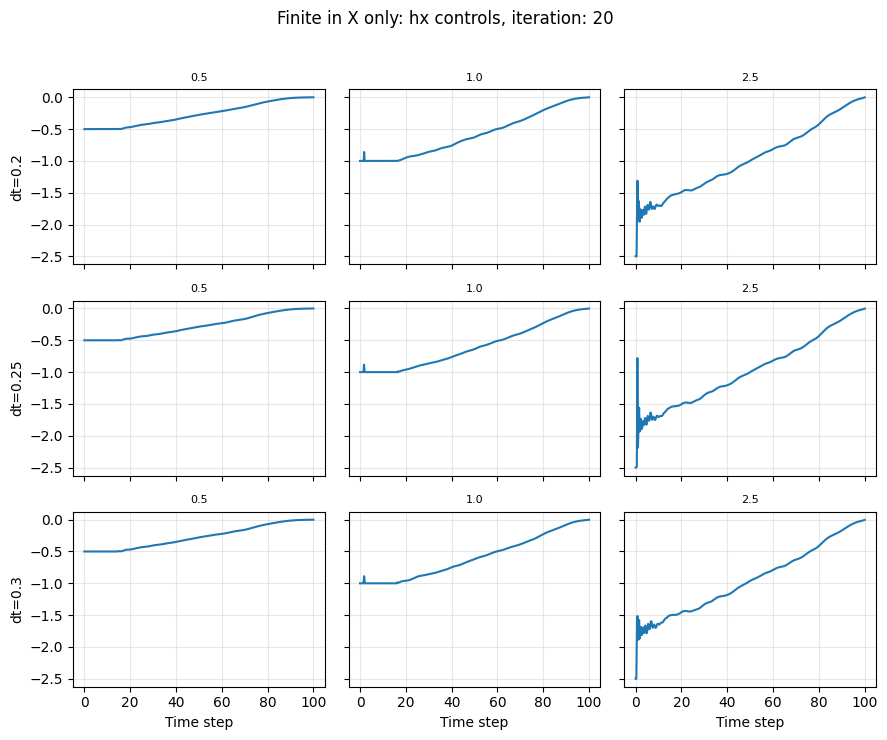

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_72918/1001995915.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


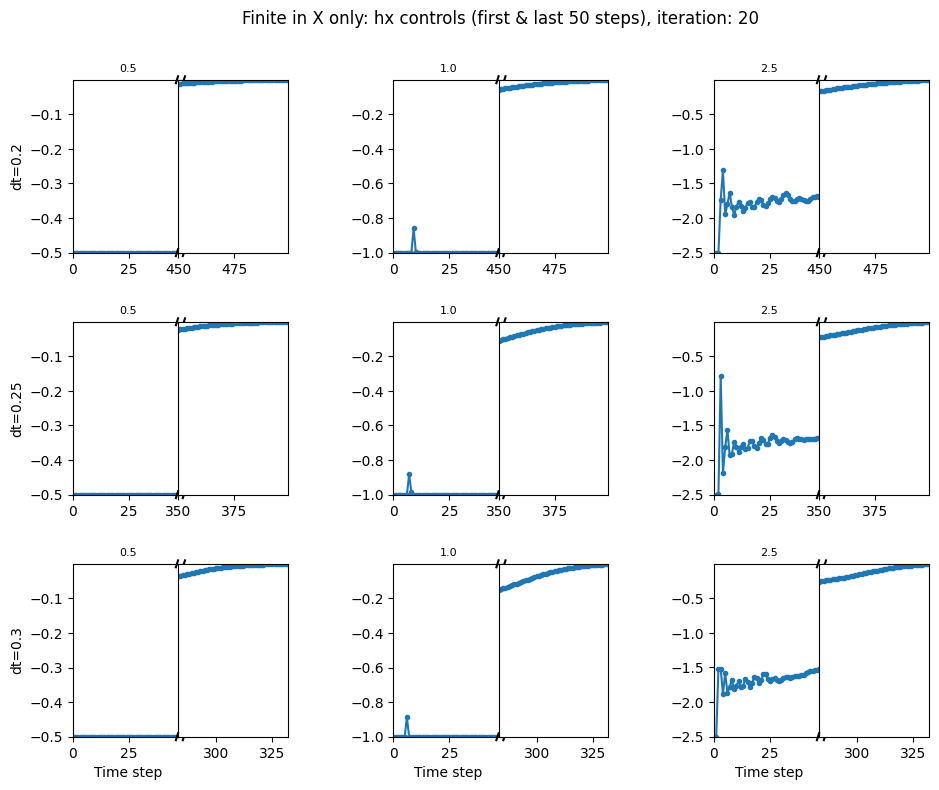

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

x_only = {}
xyz_all = {}

def load_opt_dict(path):
    try:
        with open(path, "rb") as f:
            return dill.load(f)
    except Exception as e:
        print(f"Failed to load {path}: {e}")
        return None
    
x_only = {}
xyz_all = {}
for folder in folders:
    parts = folder.split("_")
    dt = float(parts[0].split("=")[1])
    x = float(parts[-3].split("=")[1])
    y = float(parts[-2].split("=")[1])
    z = float(parts[-1].split("=")[1])
    
    if y == 0 and z == 0 and x > 0:
        x_only.setdefault(dt, []).append((x, folder))
    elif x > 0 and y > 0 and z > 0:
        xyz_all.setdefault(dt, []).append(((x, y, z), folder))

def load_opt_dict(path):
    try:
        with open(path, "rb") as f:
            return dill.load(f)
    except Exception as e:
        print(f"Failed to load {path}: {e}")
        return None

def get_controls(folder,iteration=-1):
    path = os.path.join(base_dir, folder, "100ps")
    opt_dict = load_opt_dict(path)
    if opt_dict is None:
        return None, None, None

    if iteration==-1:
        x_ctrl = opt_dict["result"].x[0::3]
        y_ctrl = opt_dict["result"].x[1::3]
        z_ctrl = opt_dict["result"].x[2::3]
    else:
        # accidently saved controls over half time-steps rather than full - just skip every second step
        x_ctrl = opt_dict["log"][iteration]["x"][:,0::3][0::2]
        y_ctrl = opt_dict["log"][iteration]["x"][:,1::3][0::2]
        z_ctrl = opt_dict["log"][iteration]["x"][:,2::3][0::2]
    return x_ctrl, y_ctrl, z_ctrl


def plot_control_grid(control_dict, title_prefix, control_label="hx",iteration=-1):
    dts = sorted(control_dict.keys())
    
    # determine number of columns for largest number of bounds per dt
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharex=True, sharey=True)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            

            hx, hy, hz = get_controls(folder,iteration)

            t=np.linspace(0,t_prot,len(hx))  

            ax = axes[i,j]
            if hx is None:
                continue
            if control_label == "hx":
                ax.plot(t,hx)
            elif control_label == "hy":
                ax.plot(t,hy)
            elif control_label == "hz":
                ax.plot(t,hz)
            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax.set_xlabel("Time step")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")
            ax.grid(alpha=0.3)
    plt.suptitle(f"{title_prefix}: {control_label} controls, iteration: {iteration}")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def plot_control_grid_zoom(control_dict, title_prefix, control_label="hx", n_edge=10,iteration=-1):
    dts = sorted(control_dict.keys())
    
    # First, find global y-axis limits
    all_y = []
    for dt in dts:
        for bounds, folder in control_dict[dt]:

            hx, hy, hz = get_controls(folder,iteration)

            if hx is None:
                continue
            ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
            yplot = np.concatenate([ydata[:n_edge], ydata[-n_edge:]])
            all_y.append(yplot)
    all_y = np.concatenate(all_y)
    global_ymin, global_ymax = np.min(all_y), np.max(all_y)
    
    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols,2.5*nrows), sharey=False)
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt], key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):
            

            hx, hy, hz = get_controls(folder,iteration)

            ydata = {"hx": hx, "hy": hy, "hz": hz}[control_label]
            N = len(ydata)

            parent = axes[i, j]
            parent.set_visible(False)


            ax_left  = inset_axes(parent, width="48%", height="100%", loc="upper left")
            ax_right = inset_axes(parent, width="48%", height="100%", loc="upper right")

            # Plot data
            ax_left.plot(range(n_edge), ydata[:n_edge], color='C0',marker='.')
            ax_right.plot(range(N-n_edge, N), ydata[-n_edge:], color='C0',marker='.')

            # Matching limits
            ymin, ymax = min(ydata), max(ydata)
            ax_left.set_ylim(ymin, ymax)
            ax_right.set_ylim(ymin, ymax)

            ax_left.set_xlim(0, n_edge-1)
            ax_right.set_xlim(N-n_edge, N-1)

            # Remove connecting spines
            ax_left.spines['right'].set_visible(True)
            ax_right.spines['left'].set_visible(True)

            # Remove duplicate ticks
            ax_right.yaxis.set_visible(False)

            # --- Draw diagonal break marks in AXIS coordinates ---
            # Transform is axis coordinates → stable, independent of y-range
            kwargs = dict(transform=ax_left.transAxes, color='k', clip_on=False)
            ax_left.plot([1, 1.02], [-0.02, 0.02], **kwargs)
            ax_left.plot([1, 1.02], [0.98, 1.02], **kwargs)

            kwargs = dict(transform=ax_right.transAxes, color='k', clip_on=False)
            ax_right.plot([-0.02, 0], [-0.02, 0.02], **kwargs)
            ax_right.plot([-0.02, 0], [0.98, 1.02], **kwargs)



            # Titles + labels
            ax_left.set_title(f"{bounds}", fontsize=8)
            if i == nrows-1:
                ax_left.set_xlabel("Time step")
            if j == 0:
                ax_left.set_ylabel(f"dt={dt}")
    
    plt.suptitle(f"{title_prefix}: {control_label} controls (first & last {n_edge} steps), iteration: {iteration}")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.subplots_adjust(hspace=0.4, wspace=0.4)

    plt.show()

current_iteration=20

plot_control_grid(x_only, "Finite in X only", control_label="hx", iteration=current_iteration)

plot_control_grid_zoom(x_only, "Finite in X only", control_label="hx", n_edge=50,iteration=current_iteration)

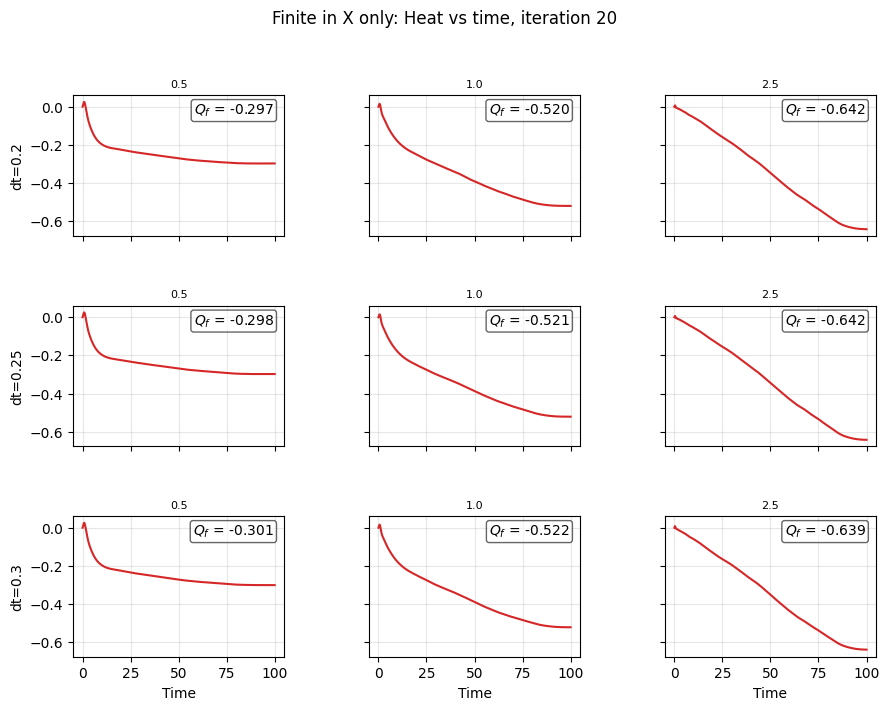

In [22]:
def get_heat(folder, iteration=-1):
    path = os.path.join(base_dir, folder, "100ps")
    opt_dict = load_opt_dict(path)
    if opt_dict is None:
        return None
    
    if iteration == -1:
        # use the final iteration
        iteration = len(opt_dict["log"]) - 1

    if "full heats" not in opt_dict["log"][iteration]:
        print(f"No heat data in {folder} at iteration {iteration}")
        return None

    return np.array(opt_dict["log"][iteration]["full heats"])


def plot_heat_grid(control_dict, title_prefix, iteration=-1):
    dts = sorted(control_dict.keys())

    ncols = max(len(control_dict[dt]) for dt in dts)
    nrows = len(dts)

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3*ncols, 2.4*nrows),
                             sharex=True, sharey=True)

    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    if ncols == 1:
        axes = np.expand_dims(axes, axis=1)

    for i, dt in enumerate(dts):
        bounds_list = sorted(control_dict[dt],
                             key=lambda x: x[0] if isinstance(x[0], float) else x[0][0])
        for j, (bounds, folder) in enumerate(bounds_list):

            heat = get_heat(folder, iteration)

            ax = axes[i, j]
            if heat is None:
                continue

            t = np.linspace(0, t_prot, len(heat))
            ax.plot(t, heat, color="C3")

            ax.set_title(f"{bounds}", fontsize=8)
            if i == nrows - 1:
                ax.set_xlabel("Time")
            if j == 0:
                ax.set_ylabel(f"dt={dt}")

            ax.grid(alpha=0.3)

            final_heat = heat[-1]

            ax.text(
                0.95, 0.95,
                f"$Q_f$ = {final_heat:.3f}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6)
            )

        

    plt.suptitle(f"{title_prefix}: Heat vs time, iteration {iteration}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0.5, wspace=0.4)
    plt.show()

plot_heat_grid(x_only, "Finite in X only", iteration=current_iteration)